In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch

import matplotlib.pyplot as plt
import utils as ut
from pathlib import Path
import pandas as pd
pd.set_option('display.max_columns', None)
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = 100
N_WORKERS = 0 # tried multiprocessing, but code hangs if not set to zero
RUN = True # Determines if notebook trains model

DEVICE # check device

device(type='cuda')

## Prepare Data

In [2]:
cwd = Path.cwd()
cutout_dir = cwd / 'data' / 'cutouts'
model_dir = cwd / 'models'

data_paths = [folder for folder in cutout_dir.iterdir() if folder.is_dir()]

In [3]:
# get random indices to create validation set (20% of training data)
indices = torch.randperm(len(data_paths), generator=torch.Generator().manual_seed(42))
n_val   = int(len(data_paths) * 0.2)

# paths for training and validation sets
train_paths = [data_paths[i] for i in indices[n_val:]]
val_paths   = [data_paths[i] for i in indices[:n_val]]

len(train_paths) + len(val_paths)

486

In [4]:
train_set = ut.GalaxyDataset(train_paths, input_size=100, transform=None, cache_path='train_set.pth')

# get averages and stdevs for each color band in the dataset
train_mean = train_set.images.mean()
train_std = train_set.images.std()

In [5]:
# transforms to apply to inputs
train_transform = transforms.Compose([ 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=(0, 360)),
    transforms.RandomPerspective(),
    transforms.Normalize(mean=train_mean, std=train_std)]) # normalize with training means and stds

# use training means and stds in normalization to treat validation data as 'unseen'
# do not randomly rotate the validation data for the same reason
val_transform = transforms.Compose([
    transforms.Normalize(mean=train_mean, std=train_std)])

# load in training and testing data with above transformss
train_set = ut.GalaxyDataset(train_paths,
                             transform=train_transform,
                             cache_path='train_set.pth')
val_set = ut.GalaxyDataset(val_paths,
                           transform=val_transform,
                           cache_path='val_set.pth')

# push all images to device for faster training
train_set.images = train_set.images.to(DEVICE).float() 
val_set.images = val_set.images.to(DEVICE).float() 
train_set.labels = train_set.labels.to(DEVICE).float() 
val_set.labels = val_set.labels.to(DEVICE).float() 

In [6]:
# check sizes
print('train: ', train_set.__len__(),
      '\nval: ',val_set.__len__(),
      '\ntotal: ', train_set.__len__() + val_set.__len__())

train:  389 
val:  97 
total:  486


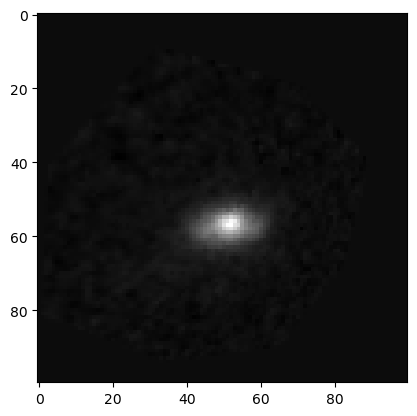

In [7]:
plt.imshow(train_set.__getitem__(1)[0][2].cpu(), cmap='gray')

## Define Model

In [8]:
import torch
import torch.nn as nn

class GalaxyClassifier(nn.Module):
    "Full Galaxy Classifier network. Combines the ConvBlock, ConvTokenizer, CvTBlock, and add a FCBlock"
    "Add softmax to appropriate outputs and scales all outputs between zero and one"
    def __init__(
        self,
        in_channels: int = 3,
        num_outputs: int = 1,
        conv_channels: int = 8,
        embed_dim: int = 8,
        num_heads: int = 2,
        num_cvt_layers: int = 1,
        fc_dim: int = 128,
        dropout: float = 0.4,
        **kwargs):

        super().__init__()

        # CNN block
        self.conv_block = ut.ConvBlock(in_channels, conv_channels)

        # CvT block
        self.tokenizer = ut.ConvTokenizer(conv_channels, embed_dim)
        self.cvt = nn.Sequential(*[ut.CvTBlock(embed_dim, num_heads, dropout=dropout)
                                   for _ in range(num_cvt_layers)])

        # FC block
        self.fc = ut.FCBlock(embed_dim, fc_dim, dropout, num_outputs)

    def forward(self, x):
        x = self.conv_block(x)
        x = self.tokenizer(x)
        x = self.cvt(x)
        x = x.mean(dim=1) # average pooling to reshape and pass into the FC layers
        x = self.fc(x)

        return x

## Define Hyperparameters

In [9]:
LR = 1e-3
WD = 1e-2

# RMSE was used in original challenge, so I use MSE and take the
# square root of it during training
weights = torch.tensor([1.0, 3.0]).to(DEVICE)
loss_func = torch.nn.CrossEntropyLoss(weight=weights)

train_losses = []
val_losses = []

In [10]:
params = {'in_channels': 3,
          'num_outputs': 2,
          'conv_channels': 3,
          'embed_dim': 16,
          'num_heads': 1,
          'num_cvt_layers': 1,
          'fc_dim': 32,
          'dropout': 0.6}

In [11]:
model = GalaxyClassifier(**params).to(DEVICE) 

optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)

model_path = None
if model_path is not None:
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

        # 3. Restore the states
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        # 4. Restore metadata variables
        start_epoch = checkpoint['epoch']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
else:
        start_epoch = 1
        train_losses = []
        val_losses = []

## Train Model

In [12]:
# 4 'dummy' images to test if model takes and gives inputs / outputs
# of correct shape without crashing
dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}") # expect [4, 1]
# calculate number of model parameters
print(f"Params: {sum(p.numel() for p in model.parameters()):,}") 

Output shape: torch.Size([4, 2])
Params: 3,574


c:\Users\harty\miniconda3\envs\torchtext\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
c:\Users\harty\miniconda3\envs\torchtext\Lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


In [ ]:
from torch.utils.data import Subset

# sets the number of galaxies used in training
train_size = len(train_set)
val_size = len(val_set)

BATCH_SIZE = 34
EPOCHS = 4

# get subsets of training and validation data based on num batches and batchsize
train_subset = Subset(train_set, range(train_size))
val_subset = Subset(val_set, range(val_size))
# set up minibatches
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE,
                            shuffle=True,  num_workers=N_WORKERS)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=N_WORKERS)

In [14]:
from tqdm.auto import tqdm, trange

if RUN == True:
    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in trange(EPOCHS, desc="Epochs", smoothing=0):
        model.train()
        running_loss = 0
        num_done = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {start_epoch + epoch} training batches", smoothing=0)
        for imgs, labels in train_bar:
            optimizer.zero_grad()
            outputs = model(imgs)
            labels = labels.long() # FOR CLASSIFICATION 
            loss = loss_func(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            num_done += imgs.size(0)
            running_avg_loss = (running_loss / num_done) ** 0.5
            train_bar.set_postfix_str(f"loss={running_avg_loss:.4f}")

        train_losses.append(running_avg_loss) # track loss only once per epoch

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        num_done = 0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch + start_epoch} val batches")
        with torch.no_grad():
            for imgs, labels in val_bar:
                outputs = model(imgs)
                labels = labels.long()
                loss = loss_func(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                num_done += imgs.size(0)

                running_avg_val_loss = (running_loss / num_done) ** 0.5
                val_bar.set_postfix_str(f"val loss={running_avg_val_loss:.4f}")
                
            val_losses.append(running_avg_val_loss)


Epochs:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 training batches:   0%|          | 0/12 [00:00<?, ?it/s]

c:\Users\harty\miniconda3\envs\torchtext\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1 val batches:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 2 training batches:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 14 val batches:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 15 training batches:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 15 val batches:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 16 training batches:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 16 val batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [15]:
if RUN: 
    model.eval()

    corr = 0
    tot = 0

    with torch.no_grad():
        for imgs, labels in val_bar:
            labels = labels.long()
            outputs = model(imgs)
            print(outputs.std(), outputs.max())

            tot += imgs.size(0)
            predictions = torch.argmax(outputs, dim=1)
            corr += (predictions == labels).float().sum()
            
corr / tot

tensor(0.2005, device='cuda:0') tensor(0.5020, device='cuda:0')
tensor(0.2074, device='cuda:0') tensor(0.5253, device='cuda:0')
tensor(0.1929, device='cuda:0') tensor(0.3214, device='cuda:0')


tensor(0.6082, device='cuda:0')

In [22]:
predictions, labels

(tensor([1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
         1, 0, 1, 1, 1], device='cuda:0'),
 tensor([1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
         0, 0, 0, 1, 1], device='cuda:0'))

In [16]:
if RUN:
    # save the model along with loss curve data so I can test different parameters and keep the best one
    # format: model_{RMSE}.pth
    torch.save({'epoch': EPOCHS + start_epoch,
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses,
                'optimizer_state_dict': optimizer.state_dict(),
                'val_losses': val_losses},
                model_dir / 'classification' / f"model_{val_losses[-1]:.3f}.pth")

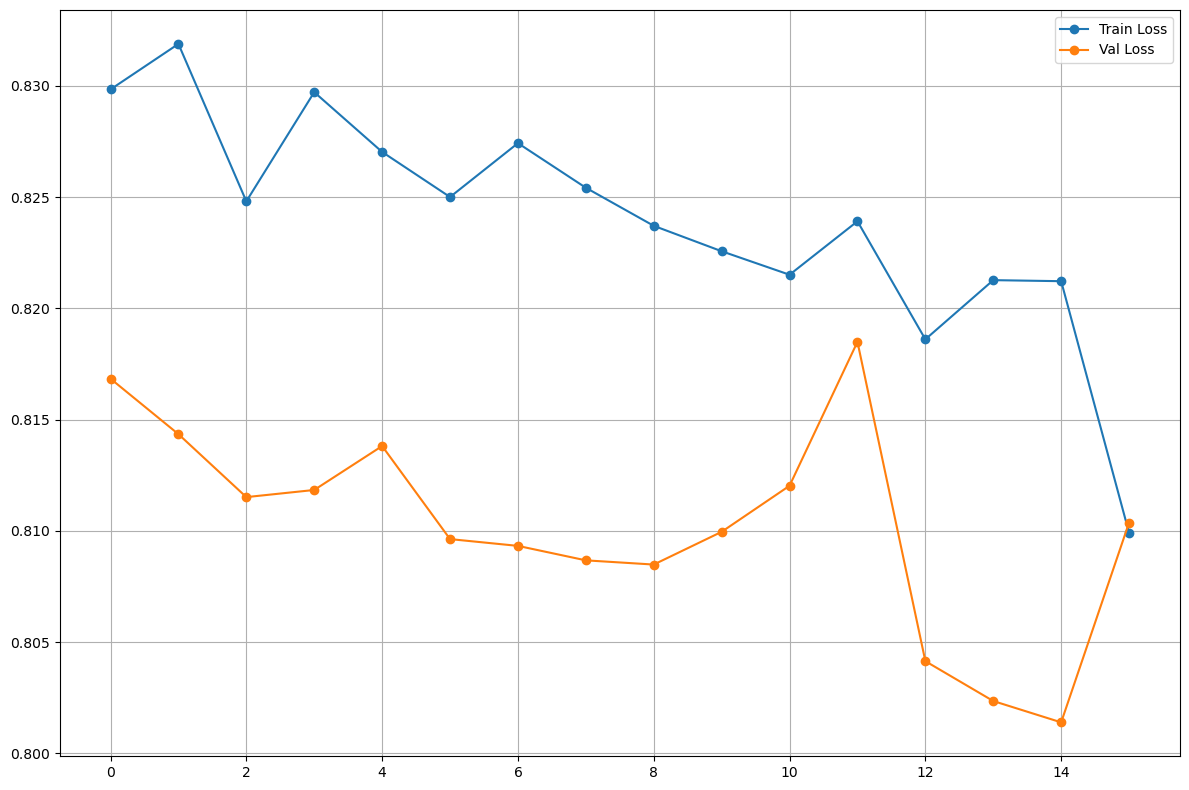

In [17]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(train_losses, label="Train Loss", marker='o')
ax.plot(val_losses, label="Val Loss", marker='o')
ax.grid()
ax.legend()
fig.tight_layout()

In [18]:
train_set.labels.std(), train_set.labels.median(), train_set.labels.max(), train_set.labels.min()

(tensor(0.4666, device='cuda:0'),
 tensor(0., device='cuda:0'),
 tensor(1., device='cuda:0'),
 tensor(0., device='cuda:0'))

In [19]:
eval = False

if eval:
    model_path = r"C:\Users\harty\Code\Galaxy-Classifier\Summer Research\models\regression\model_3.363.pth" # new model path 

    params = {'in_channels': 3,
            'num_outputs': 1,
            'conv_channels': 8,
            'embed_dim': 32,
            'num_heads': 2,
            'num_cvt_layers': 1,
            'fc_dim': 32,
            'dropout': 0.4}

    model = GalaxyClassifier(**params).to(DEVICE) # untrained model with same dimensions as the one in model_path

    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    corr = 0
    tot = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs)
            print(outputs.std(), outputs.max())

            tot += imgs.size(0)
            corr += sum(1 for x, y in zip(labels, outputs) if x >= 15 and y >= 15)
            corr += sum(1 for x, y in zip(labels, outputs) if x < 15 and y < 15)
            
    corr / tot